In [42]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve
import nifty8.re as jft

from jax.lax import slice as jax_slice
from jax.scipy.signal import fftconvolve
from functools import partial

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type, domain_tree, model_init, correlated_field_model, optimize_kl

jax.config.update("jax_enable_x64", True)

key = jax.random.PRNGKey(123)

In [43]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1, distances=(1.,1.)):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)
        check_type(distances, tuple, float)

        self.space = space
        self.center = center
        self.factor = factor
        self.shape = tuple(d*self.factor for d in self.space)
        self.distances = distances

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor}, distances={self.distances})'
    
    def __mul__(self, other):
        return self.multiply_space(other)
    
    def __rmul__(self, other):
        return self.__mul__(other)

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def dis(self):
        return np.array(self.distances) / self.factor
    
    @property
    def coos(self):
        coos = np.indices(self.shp).astype(float)
        coos_T = coos.T.reshape(-1, 2)
        coos_T -= 0.5 * (self.shp - 1)
        coos_T /= self.factor
        coos_T += self.cen
        return coos_T.reshape(coos.T.shape).T

    @property
    def llp(self):
        return self.cen - 0.5 * (self.shp - 1) / self.factor

    @property
    def urp(self):
        return self.cen + 0.5 * (self.shp - 1) / self.factor

    def update(self, space=None, center=None, factor=None, distances=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        distances = self.distances if distances is None else distances
        return SignalGrid(space, center, factor, distances)
    
    def multiply_space(self, factor):
        return SignalGrid.update(self, space=tuple(int(si * factor) for si in self.space))



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
        in_grid = in_grid.update(factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center or in_grid.space != out_grid.space:
        out_array = jnp.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif * in_grid.factor, 0)
        in_max = np.minimum(urp_dif * in_grid.factor + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif * out_grid.factor, 0)
        out_max = np.minimum(out_grid.shp - urp_dif * out_grid.factor, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array = out_array.at[out_slc].set(in_array[in_slc])
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

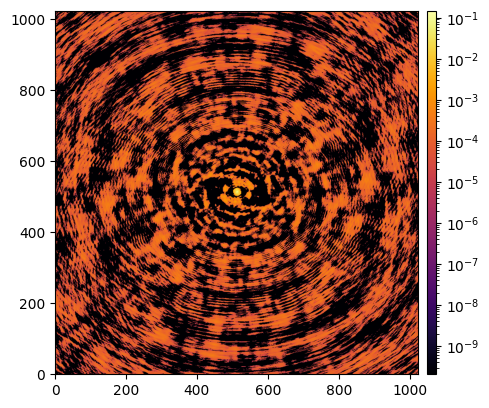

In [44]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()

space = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space)
kernel = compute_psf_kernel(RNR_l)

plot_arrays(kernel, norm='log', dpi=100)

In [45]:
class SignalModel(jft.Model):

    def __init__(self, grid, i0, prefix='sm'):
        self.grid = grid
        self.i0 = i0
        self.prefix = prefix
        super().__init__(domain=self.i0.domain, init=self.i0.init)

    def __call__(self, x, *, out_grid=None):
        res = jnp.exp(self.i0(x))
        if out_grid:
            return map_array(res, self.grid, out_grid)
        return res


class ComponentModel(jft.Model):

    def __init__(self, grid, background, *components):
        self.grid = grid
        self.models = (background, ) + components
        self.background = background
        self.components = components

        super().__init__(
            domain = jft.Vector(domain_tree(self.models)), 
            init = model_init(self.models),
        )

    def __call__(self, x, *, out_grid=None):
        out_grid = out_grid if out_grid else self.grid
        res = jnp.zeros(out_grid.shape)
        for m in self.models:
            res += m(x, out_grid=out_grid)
        return res

In [60]:
class HighResResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.kernel = kernel
        self.dvol = model.grid.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig = self.model(x)
        rsp = fftconvolve(sig, self.kernel, mode='same') * self.dvol
        return rsp



class LowResResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.factor = model.grid.factor 
        self.kernel = downsample(kernel, self.factor)
        self.dvol = self.model.grid.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig = self.model(x)
        fsig = downsample(sig, self.factor)
        frsp = fftconvolve(fsig, self.kernel, mode='same') * self.dvol * (self.factor**2)
        rsp = upsample(frsp, self.factor)
        return rsp



def build_multi_kernel(kernel, factors):
    ksize = kernel.shape[0]
    fsize = ksize // max(factors)

    mkernel = np.zeros((len(factors), fsize, fsize))
    for i,f in enumerate(factors):
        ker = np.zeros_like(kernel)
        if i == 0:
            slc_in = slice(0, 0)
            slc_out = slice(ksize//2 - fsize//2, ksize//2 + fsize//2)
        else:
            slc_in = slc_out
            slc_out = slice(ksize//2 - f*fsize//2, ksize//2 + f*fsize//2)
        ker[slc_out, slc_out] = kernel[slc_out, slc_out]
        ker[slc_in, slc_in] = 0
        mkernel[i] = downsample(ker[slc_out, slc_out], f)

    return mkernel 



class MultiKernelResponse(jft.Model):
    def __init__(self, model, kernel):
        self.model = model
        self.factors = np.array([f for f in [1,2,4,8] if f <= model.grid.factor])
        print('factors:', self.factors)
        self.kernels = build_multi_kernel(kernel, self.factors)
        plot_arrays(self.kernels, label=[f'factor = {f/self.factors.max()}' for f in self.factors], norm='log', dpi=100, rows=1, vmin=self.kernels[self.kernels>0].min(), vmax=self.kernels.max())
        self.dvol = model.grid.dis.prod()
        super().__init__(domain = self.model.domain, init = self.model.init)

    def __call__(self, x):
        sig = self.model(x)
        rsp = jnp.zeros_like(sig)
        for i,f in enumerate(self.factors):
            fsig = downsample(sig, f)
            frsp = fftconvolve(fsig, self.kernels[i], mode='same') * self.dvol * (f**2)
            rsp += upsample(frsp, f)
        return rsp

SignalGrid(space=(128, 128), center=(0, 0), factor=4, distances=(0.000272707695624114, 0.000272707695624114))
Vector(
	{'bg fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg loglogavgslope': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg xi': ShapeWithDtype(shape=(512, 512), dtype=<class 'numpy.float64'>),
	 'bg zeromode': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 't0 fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 't0 loglogavgslope': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 't0 xi': ShapeWithDtype(shape=(80, 120), dtype=<class 'numpy.float64'>),
	 't0 zeromode': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 't1 fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 't1 loglogavgslope': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 't1 xi': ShapeWithDtype(shape=(48, 96), dtype=<class 'numpy.float64'>),
	 't1 zeromode': ShapeWithDtype(sha

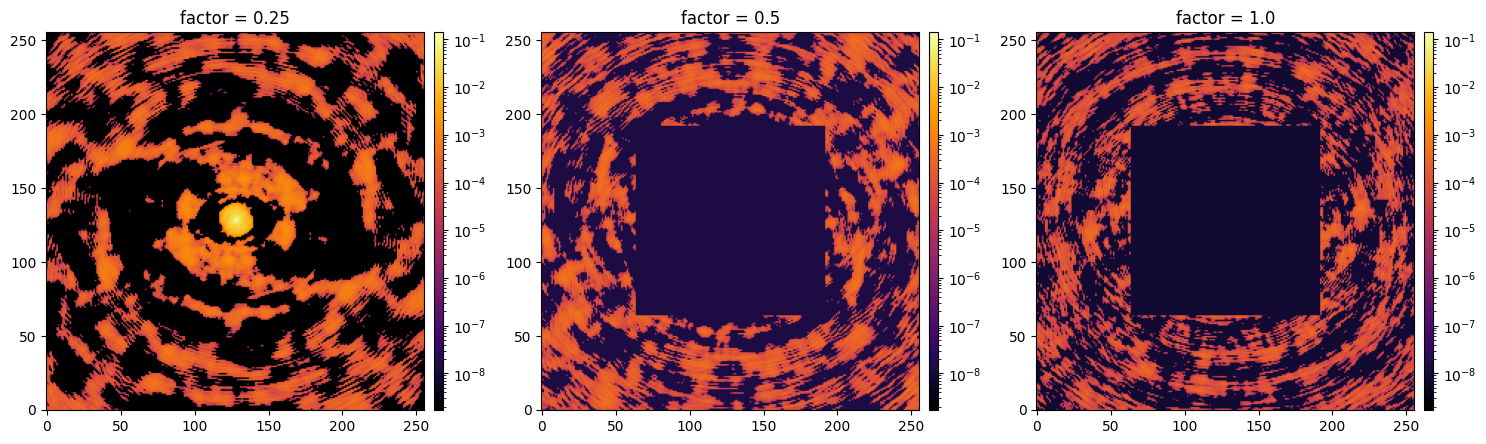

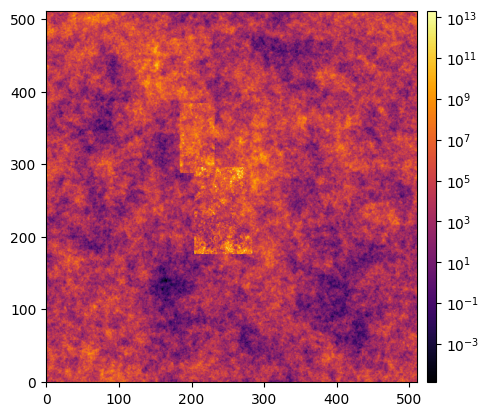

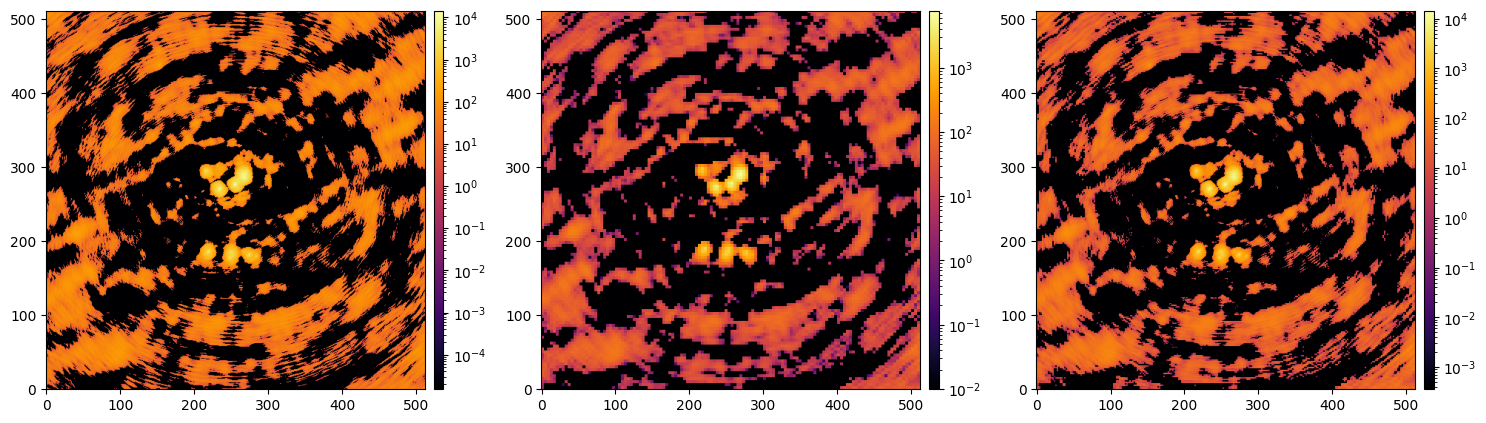

In [61]:
shape = (512, 512)
fmax = 4

space = SignalSpace.build(shape=tuple(s//fmax for s in shape), fov=('2deg', '2deg'))

grid = SignalGrid(space=tuple(s//fmax for s in shape), center=(0,0), factor=fmax, distances=space.distances)
print(grid)

bg_grid = grid.update(factor=1)
bg, pw = correlated_field_model(
    prefix='bg ',
    shape=grid.shape,
    distances=grid.distances,
    offset_mean=8,
    offset_std=(1,1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
bg_signal = SignalModel(grid, bg, prefix='bg')

t0_grid = SignalGrid(space=(80//fmax, 120//fmax), center=(-12//fmax,-20//fmax), factor=fmax, distances=space.distances)
t0, pw = correlated_field_model(
    prefix='t0 ',
    shape=t0_grid.shape,
    distances=t0_grid.distances,
    offset_mean=12,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
t0_signal = SignalModel(t0_grid, t0, prefix='t0')

t1_grid = SignalGrid(space=(48//fmax, 96//fmax), center=(-48//fmax, 80//fmax), factor=fmax, distances=space.distances)
t1, pw = correlated_field_model(
    prefix='t1 ',
    shape=t1_grid.shape,
    distances=t1_grid.distances,
    offset_mean=12,
    offset_std=(1,0.1),
    fluctuations=(5,1),
    loglogavgslope=(-2,0.5),
)
t1_signal = SignalModel(t1_grid, t1, prefix='t1')

signal = ComponentModel(grid, bg_signal, t0_signal, t1_signal)
print(signal.domain)


hr_response = HighResResponse(signal, kernel)

lr_response = LowResResponse(signal, kernel)

mk_response = MultiKernelResponse(signal, kernel)


key, subkey = jax.random.split(key)
prior_xi = signal.init(subkey)

plot_arrays(signal(prior_xi), rows=1, norm='log')

plot_arrays([hr_response(prior_xi), lr_response(prior_xi), mk_response(prior_xi)], rows=1, norm='log')

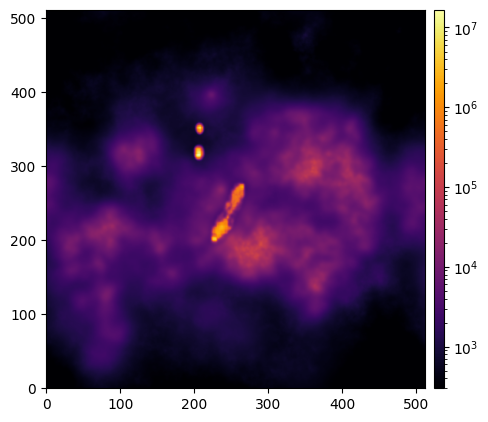

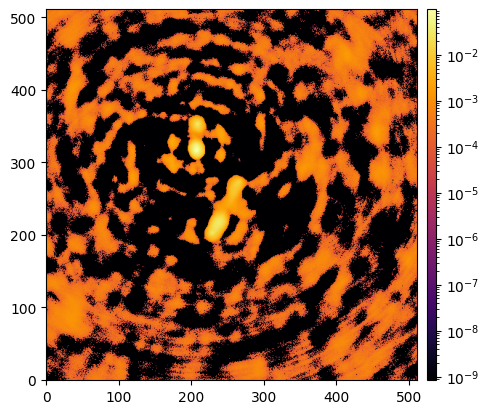

In [16]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')


sky_bg = optim_cfg.instantiate_sec('sky_bg.3')
sky_o0 = optim_cfg.instantiate_sec('sky_o0.3')
sky_o1 = optim_cfg.instantiate_sec('sky_o1.3')
sky_o2 = optim_cfg.instantiate_sec('sky_o2.3')
sky_t0 = optim_cfg.instantiate_sec('sky_t0.3')
sky_p0 = optim_cfg.instantiate_sec('sky_p0.3')



with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    samples, *_ = pickle.load(f)

rec_bg = samples.mean(sky_bg)
rec_o0 = map_signal(samples.mean(sky_o0), sky_o0.space, sky_bg.space)
rec_o1 = map_signal(samples.mean(sky_o1), sky_o1.space, sky_bg.space)
rec_o2 = map_signal(samples.mean(sky_o2), sky_o2.space, sky_bg.space)
# rec_t0 = samples.mean(sky_t0)
# rec_p0 = samples.mean(sky_p0)

rec = rec_bg + rec_o0 + rec_o1 + rec_o2 #+ rec_t0 + rec_p0
# rec = downsample(rec, 2)


def generate_data(rec, kernel, grid, n_std=1e-4):
    truth = jax_convolve(rec, kernel, mode='same', method='fft') * grid.dis.prod()
    noise = n_std * jax.random.normal(key, truth.shape)
    data = truth + noise
    return data


data = generate_data(rec, kernel, grid)


plot_arrays(rec, norm='log', vmin=3e2, vmax=rec.max(), dpi=100)
plot_arrays(data, rows=1, norm='log')

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+2.3930e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.8±     0.0, avg:   +0.093±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:   0.015±     0.0, avg:    +0.12±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.054±     0.0, avg:    -0.23±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00011±     0.0, avg: -6.3e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00021±     0.0, avg:   -0.015±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     0.3±     0.0, avg:    +0.55±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:    0.11±     0.0, avg:    -0.33±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0016±     0.0, avg: -0.00017±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.038±     0.0, avg:    +0.19±     0

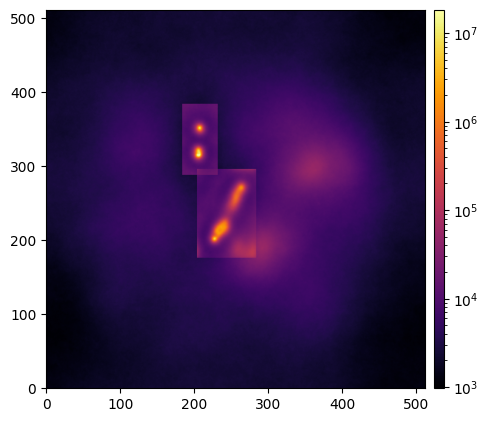

OPTIMIZE_KL: Starting 0002
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0002 ⛰:+1.6486e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.3±     0.0, avg:   +0.087±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:   0.084±     0.0, avg:    +0.29±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.083±     0.0, avg:    -0.29±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00012±     0.0, avg: -8.5e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00068±     0.0, avg:   -0.026±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.48±     0.0, avg:    +0.69±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.087±     0.0, avg:    -0.29±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0019±     0.0, avg: -0.00024±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.064±   

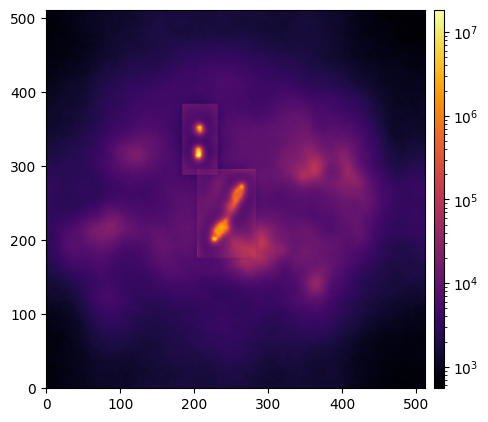

OPTIMIZE_KL: Starting 0003
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0003 ⛰:+1.5890e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.2±     0.0, avg:   +0.066±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.21±     0.0, avg:    +0.46±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.074±     0.0, avg:    -0.27±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00013±     0.0, avg: -1.1e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00066±     0.0, avg:   -0.026±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     0.7±     0.0, avg:    +0.84±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.056±     0.0, avg:    -0.24±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0022±     0.0, avg: -0.00031±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.089±   

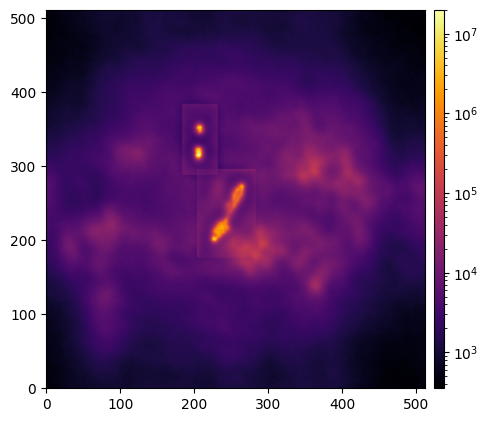

OPTIMIZE_KL: Starting 0004
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0004 ⛰:+1.5777e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.2±     0.0, avg:   +0.058±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.23±     0.0, avg:    +0.48±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.066±     0.0, avg:    -0.26±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00013±     0.0, avg: -1.1e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00026±     0.0, avg:   -0.016±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.72±     0.0, avg:    +0.85±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.057±     0.0, avg:    -0.24±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0022±     0.0, avg: -0.00032±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.094±   

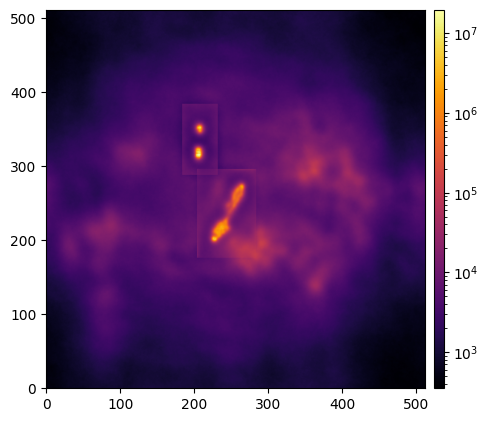

OPTIMIZE_KL: Starting 0005
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0005 ⛰:+1.5389e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.2±     0.0, avg:   +0.049±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.98±     0.0, avg:    +0.99±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²: 0.00019±     0.0, avg:   -0.014±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00016±     0.0, avg: -1.3e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:   0.001±     0.0, avg:   -0.032±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     1.0±     0.0, avg:     +1.0±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:    0.02±     0.0, avg:    -0.14±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0026±     0.0, avg: -0.00042±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:    0.12±   

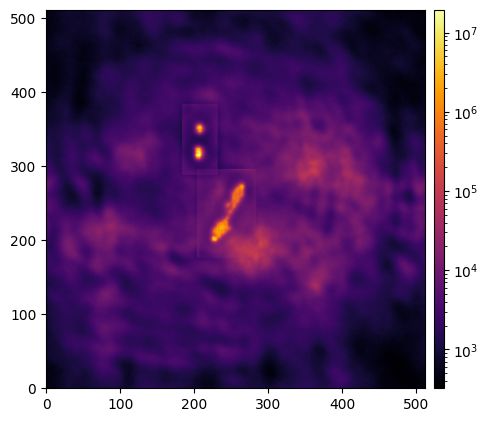

In [17]:
lh_dct = dict(
    data = data,
    model = mk_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

mk_samples, _ = optimize_kl(
    likelihood=lh_dct, 
    key=45,
    n_total_iterations=5,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=10,
            maxiter=10,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+2.2272e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.7±     0.0, avg:   +0.093±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:   0.012±     0.0, avg:    +0.11±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.044±     0.0, avg:    -0.21±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00011±     0.0, avg: -6.1e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00031±     0.0, avg:   -0.018±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.27±     0.0, avg:    +0.52±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:    0.11±     0.0, avg:    -0.33±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0015±     0.0, avg: -0.00017±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.035±     0.0, avg:    +0.19±     0

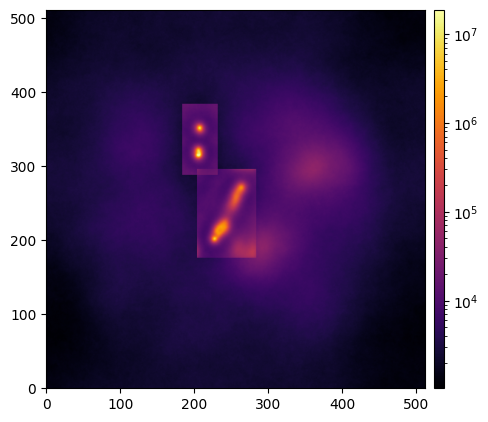

OPTIMIZE_KL: Starting 0002
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0002 ⛰:+1.4789e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.1±     0.0, avg:     +0.1±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:   0.048±     0.0, avg:    +0.22±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.087±     0.0, avg:    -0.29±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00011±     0.0, avg: -7.5e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00018±     0.0, avg:   -0.013±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.35±     0.0, avg:    +0.59±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.099±     0.0, avg:    -0.32±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0017±     0.0, avg: -0.00021±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.053±   

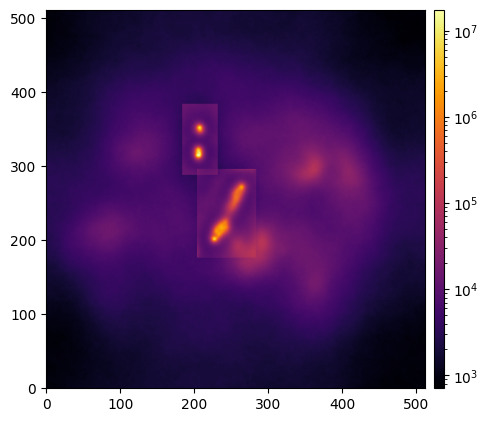

OPTIMIZE_KL: Starting 0003
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0003 ⛰:+1.3550e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.079±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.11±     0.0, avg:    +0.33±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.093±     0.0, avg:     -0.3±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00012±     0.0, avg: -9.4e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:  0.0012±     0.0, avg:   -0.035±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.54±     0.0, avg:    +0.74±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.072±     0.0, avg:    -0.27±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:   0.002±     0.0, avg: -0.00026±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.071±   

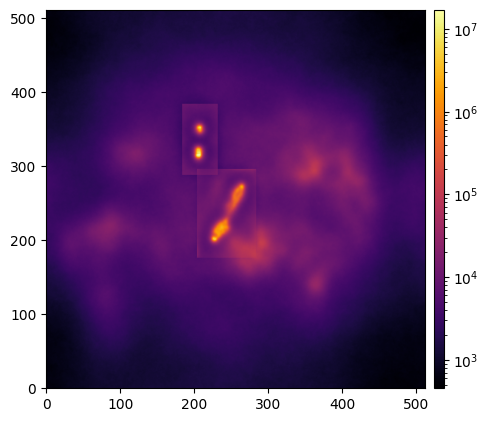

OPTIMIZE_KL: Starting 0004
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0004 ⛰:+1.3153e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.034±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.38±     0.0, avg:    +0.62±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.078±     0.0, avg:    -0.28±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00013±     0.0, avg: -1.3e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:  0.0032±     0.0, avg:   +0.056±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.94±     0.0, avg:    +0.97±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.026±     0.0, avg:    -0.16±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0024±     0.0, avg: -0.00034±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:    0.11±   

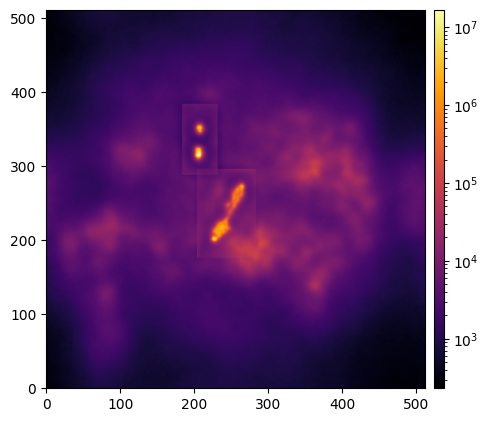

OPTIMIZE_KL: Starting 0005
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0005 ⛰:+1.3087e+05
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.0±     0.0, avg:   +0.023±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.57±     0.0, avg:    +0.76±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.059±     0.0, avg:    -0.24±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00014±     0.0, avg: -1.5e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:   0.016±     0.0, avg:    +0.13±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:     1.1±     0.0, avg:     +1.1±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.011±     0.0, avg:     -0.1±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0025±     0.0, avg: -0.00038±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:    0.12±   

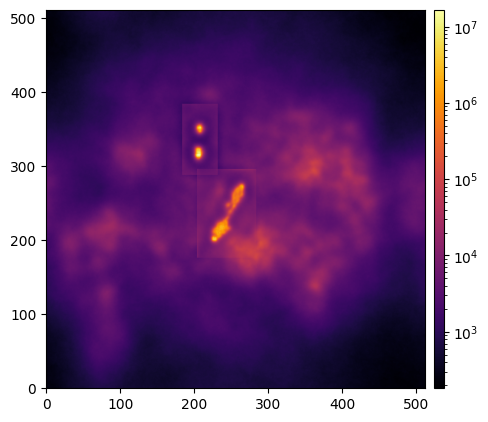

In [18]:
lh_dct = dict(
    data = data,
    model = hr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

hr_samples, _ = optimize_kl(
    likelihood=lh_dct,
    key=45,
    n_total_iterations=5,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=10,
            maxiter=10,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

OPTIMIZE_KL: Starting 0001


s == p == set()


N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0001 ⛰:+2.6058e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:   2e+01±     0.0, avg:     +0.1±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:   0.017±     0.0, avg:    +0.13±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.058±     0.0, avg:    -0.24±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00011±     0.0, avg: -6.3e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00023±     0.0, avg:   -0.015±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.33±     0.0, avg:    +0.57±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:     0.1±     0.0, avg:    -0.32±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0015±     0.0, avg: -0.00018±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.036±     0.0, avg:    +0.19±     0

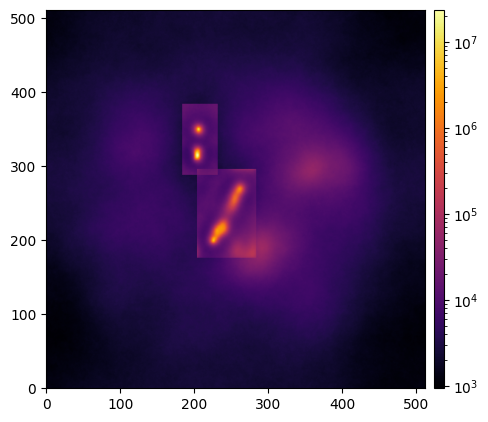

OPTIMIZE_KL: Starting 0002
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0002 ⛰:+2.5406e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 1.9e+01±     0.0, avg:    +0.12±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.06±     0.0, avg:    +0.24±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.096±     0.0, avg:    -0.31±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00011±     0.0, avg: -7.8e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00013±     0.0, avg:   -0.011±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.46±     0.0, avg:    +0.68±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.075±     0.0, avg:    -0.27±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0018±     0.0, avg: -0.00022±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.054±   

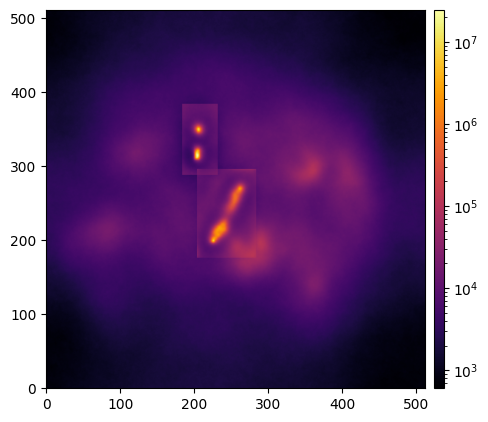

OPTIMIZE_KL: Starting 0003
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0003 ⛰:+2.5307e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 1.9e+01±     0.0, avg:    +0.11±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:     0.1±     0.0, avg:    +0.32±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:     0.1±     0.0, avg:    -0.32±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00012±     0.0, avg:   -9e-06±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00069±     0.0, avg:   -0.026±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.57±     0.0, avg:    +0.75±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.051±     0.0, avg:    -0.23±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0019±     0.0, avg: -0.00024±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.061±   

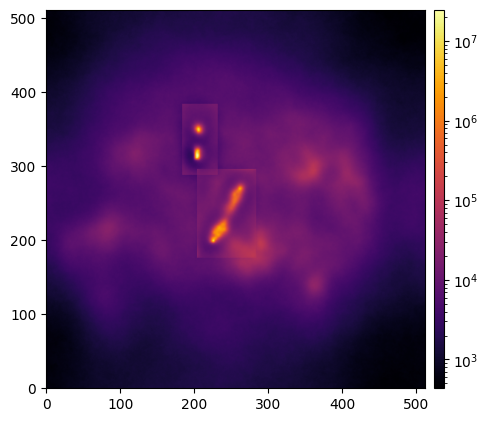

OPTIMIZE_KL: Starting 0004
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0004 ⛰:+2.5238e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 1.9e+01±     0.0, avg:    +0.11±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.27±     0.0, avg:    +0.52±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:    0.11±     0.0, avg:    -0.33±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00013±     0.0, avg: -1.2e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²:  0.0013±     0.0, avg:   -0.036±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.76±     0.0, avg:    +0.87±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.028±     0.0, avg:    -0.17±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0021±     0.0, avg: -0.00025±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.071±   

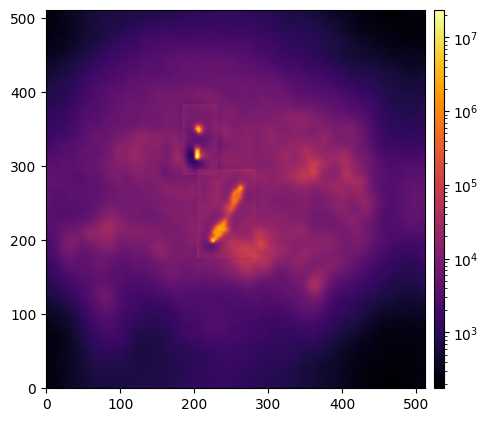

OPTIMIZE_KL: Starting 0005
N: Iteration Limit Reached!
OPTIMIZE_KL: Iteration 0005 ⛰:+2.5206e+06
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²: 1.9e+01±     0.0, avg:    +0.12±     0.0, #dof: 262144'

OPTIMIZE_KL: Prior residual(s):
bg fluctuations         :: 'reduced χ²:    0.66±     0.0, avg:    +0.81±     0.0, #dof:      1'
bg loglogavgslope       :: 'reduced χ²:   0.071±     0.0, avg:    -0.27±     0.0, #dof:      1'
bg xi                   :: 'reduced χ²: 0.00014±     0.0, avg: -1.5e-05±     0.0, #dof: 262144'
bg zeromode             :: 'reduced χ²: 0.00074±     0.0, avg:   -0.027±     0.0, #dof:      1'
t0 fluctuations         :: 'reduced χ²:    0.93±     0.0, avg:    +0.96±     0.0, #dof:      1'
t0 loglogavgslope       :: 'reduced χ²:   0.014±     0.0, avg:    -0.12±     0.0, #dof:      1'
t0 xi                   :: 'reduced χ²:  0.0022±     0.0, avg: -0.00027±     0.0, #dof:   9600'
t0 zeromode             :: 'reduced χ²:   0.073±   

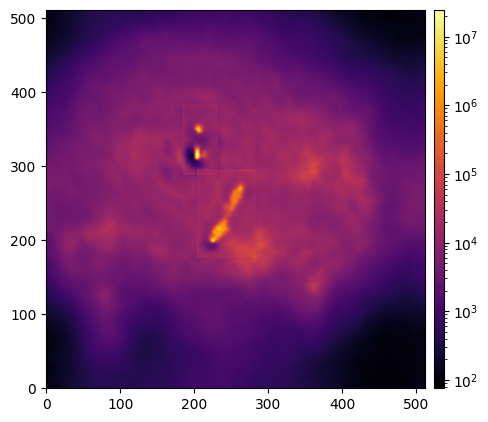

In [19]:
lh_dct = dict(
    data = data,
    model = lr_response,
    noise_cov_inv = None,
    noise_std_inv = (1e-4)**-1,
)

def callback(samples, it):
    plot_arrays([samples.mean(signal)], norm='log')

lr_samples, _ = optimize_kl(
    likelihood=lh_dct,
    key=45,
    n_total_iterations=5,
    n_samples=0,
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(
                name=None
            ),
            miniter=10,
            maxiter=10,
        ),
    ),
    callback=callback,
    sample_mode='linear_resample',
)

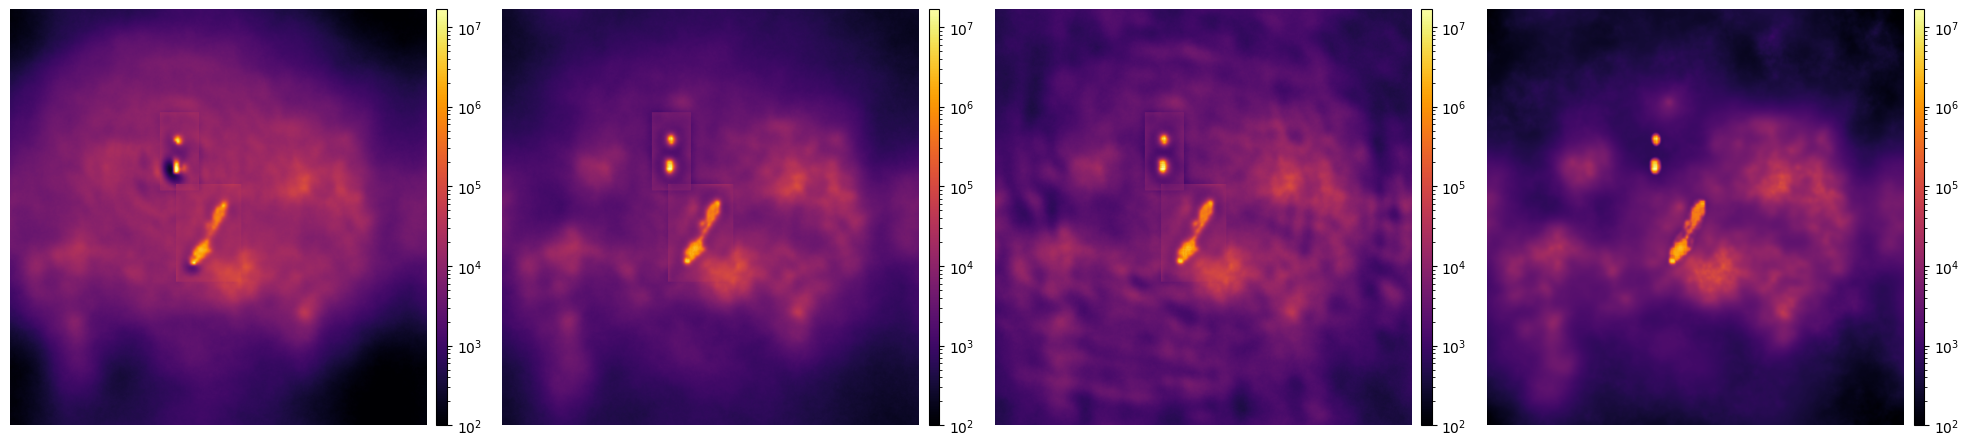

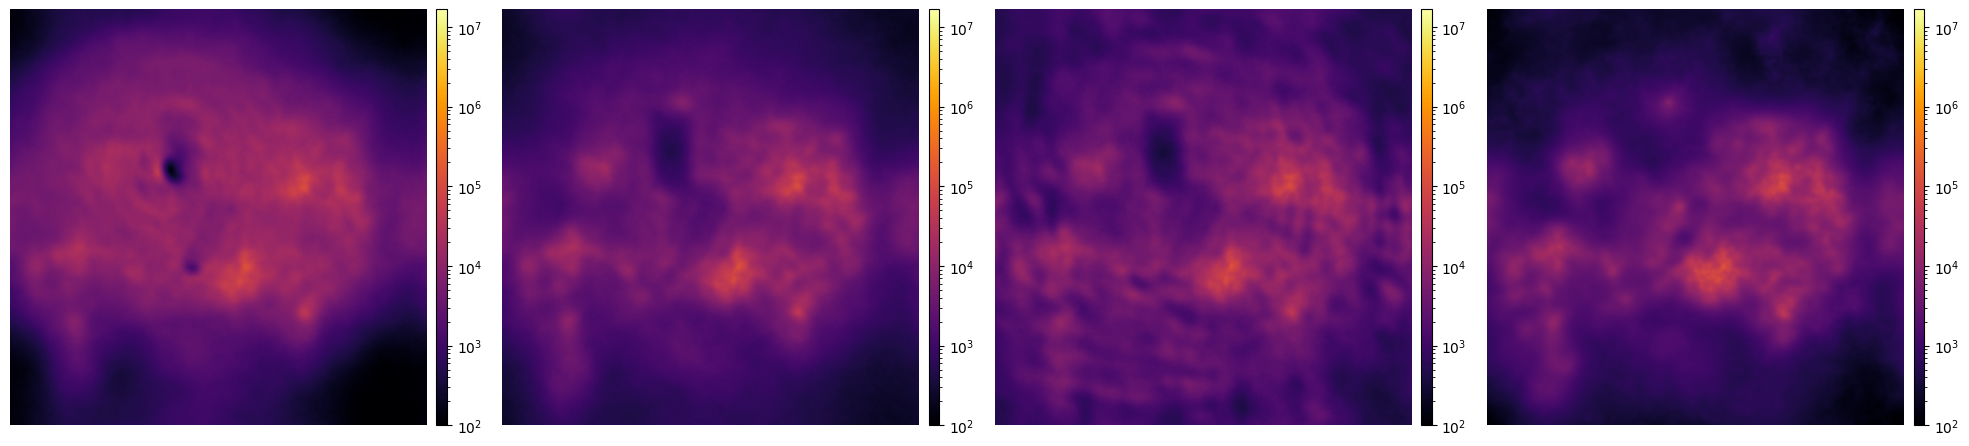

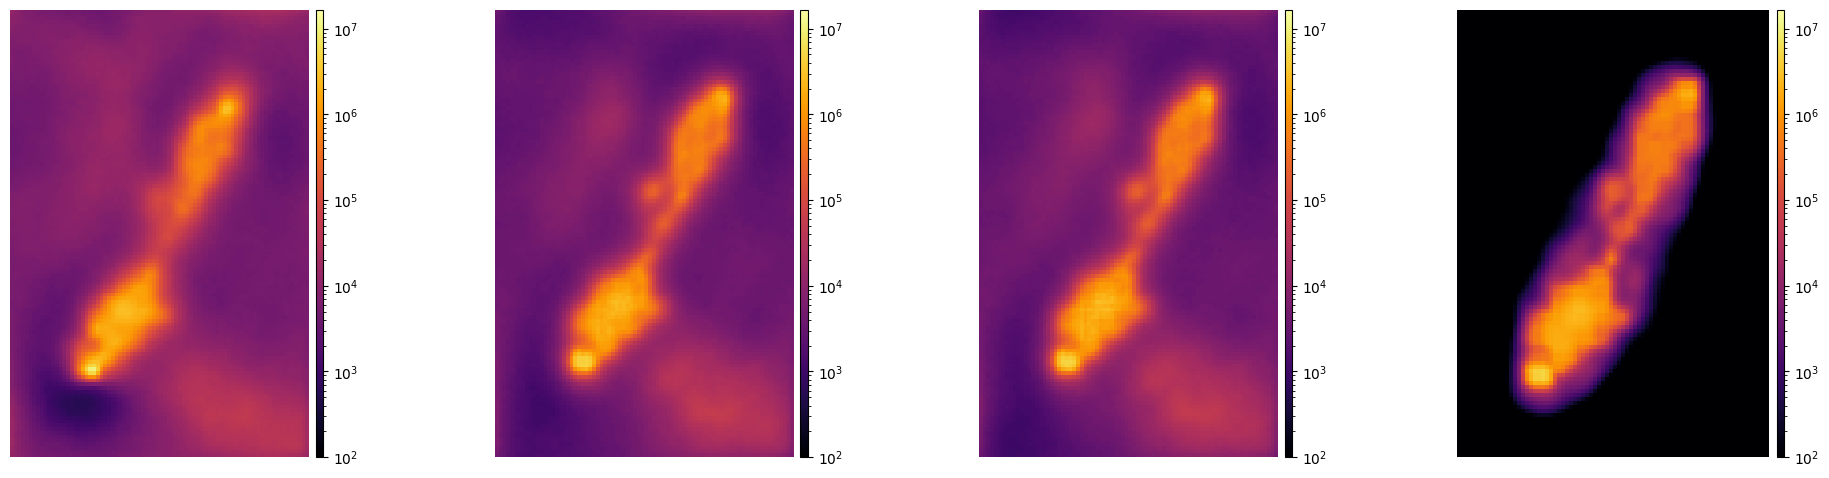

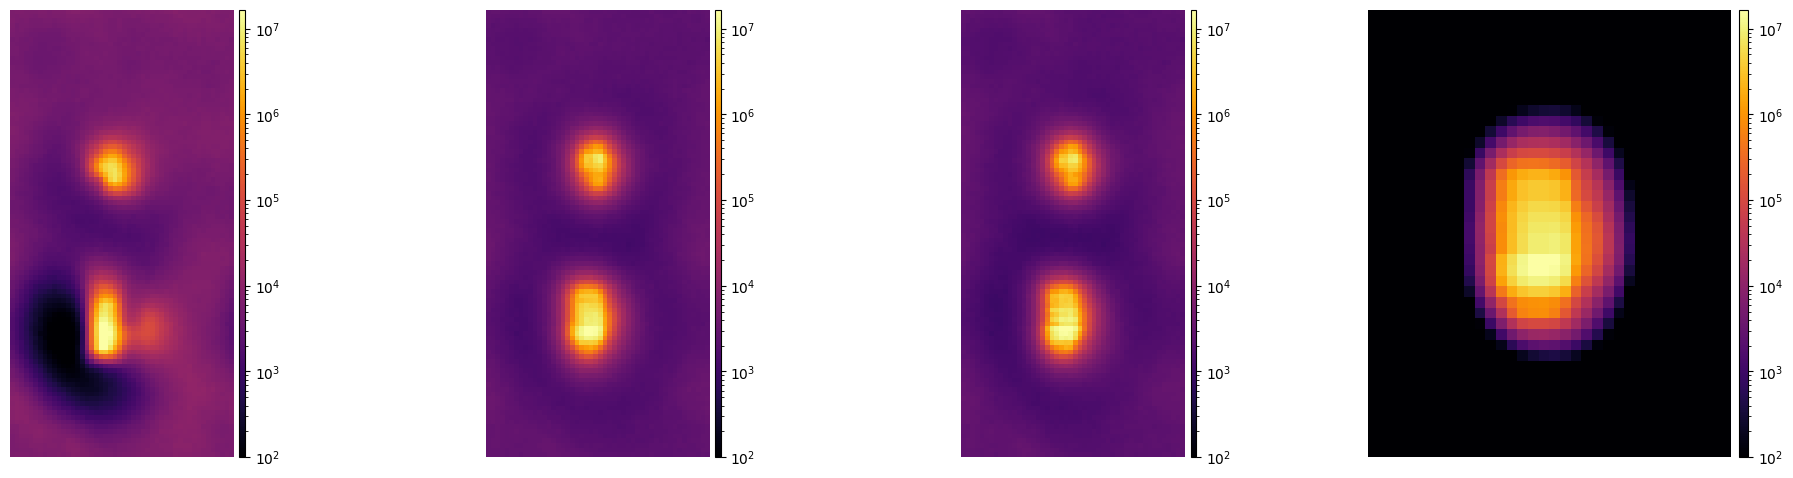

In [20]:
plot_arrays([lr_samples.mean(signal), hr_samples.mean(signal), mk_samples.mean(signal), rec], norm='log', rows=1, ticks=0, vmin=1e2, vmax=rec.max())

plot_arrays([lr_samples.mean(bg_signal), hr_samples.mean(bg_signal), mk_samples.mean(bg_signal), samples.mean(sky_bg)], norm='log', rows=1, ticks=0, vmin=1e2, vmax=rec.max())

plot_arrays([lr_samples.mean(t0_signal), hr_samples.mean(t0_signal), mk_samples.mean(t0_signal), samples.mean(sky_o0)], norm='log', rows=1, ticks=0, vmin=1e2, vmax=rec.max())

plot_arrays([lr_samples.mean(t1_signal), hr_samples.mean(t1_signal), mk_samples.mean(t1_signal), samples.mean(sky_o1)], norm='log', rows=1, ticks=0, vmin=1e2, vmax=rec.max())